# India Green Bond Trend Analysis

#

## Import Libraries and Load Data from MySQL

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from db_connection import fetch_data_from_database

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
df = fetch_data_from_database()
print("Shape of dataset (rows, columns):", df.shape)
print(df.head())


Shape of dataset (rows, columns): (120, 15)
   Sr_No                                             Issuer  \
0      1             L&T Infrastructure Finance Company Ltd   
1      2                     Tata Cleantech Capital Limited   
2      3  Indian Renewable Energy Development Agency Lim...   
3      4  Indian Renewable Energy Development Agency Lim...   
4      5                              Ghaziabad Nagar Nigam   

                  Issuer_Type ESG_Category Issuance_Date  Issuance_Year  \
0       Public/Listed Company        Green    2017-06-29           2017   
1       Public/Listed Company        Green    2018-12-18           2018   
2       Government/PSU Agency        Green    2019-01-03           2019   
3       Government/PSU Agency        Green    2019-01-17           2019   
4  Municipal/Urban Local Body        Green    2021-03-31           2021   

  Listing_Date  Listing_Lag_Days Maturity_Date  Tenure_Years  \
0   2017-07-04                 5    2024-11-18          7.00  

#

## All Data Information

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sr_No                120 non-null    int64  
 1   Issuer               120 non-null    str    
 2   Issuer_Type          120 non-null    str    
 3   ESG_Category         120 non-null    str    
 4   Issuance_Date        120 non-null    object 
 5   Issuance_Year        120 non-null    int64  
 6   Listing_Date         120 non-null    object 
 7   Listing_Lag_Days     120 non-null    int64  
 8   Maturity_Date        120 non-null    object 
 9   Tenure_Years         120 non-null    float64
 10  Amount_Raised_Cr     120 non-null    float64
 11  Coupon_Percent       120 non-null    float64
 12  Is_Serial_Tranche    120 non-null    str    
 13  Unique_Issuance_Row  120 non-null    str    
 14  ISIN                 120 non-null    str    
dtypes: float64(3), int64(3), object(3), str(6)
memory u

In [4]:
print(df.describe())


           Sr_No  Issuance_Year  Listing_Lag_Days  Tenure_Years  \
count  120.00000     120.000000        120.000000    120.000000   
mean    19.55000    2023.466667          3.966667      5.485667   
std     10.44783       2.379652          3.335406      2.416367   
min      1.00000    2017.000000          0.000000      1.000000   
25%      9.75000    2021.000000          1.000000      3.000000   
50%     21.50000    2024.000000          3.000000      5.000000   
75%     31.00000    2026.000000          6.000000      7.000000   
max     33.00000    2026.000000         18.000000     10.020000   

       Amount_Raised_Cr  Coupon_Percent  
count        120.000000      120.000000  
mean         438.235500        7.811833  
std         1281.663891        0.767122  
min           16.000000        6.350000  
25%          150.000000        7.635000  
50%          200.000000        8.020000  
75%          271.250000        8.100000  
max        10000.000000       11.250000  


In [5]:
print(df.isnull().sum())


Sr_No                  0
Issuer                 0
Issuer_Type            0
ESG_Category           0
Issuance_Date          0
Issuance_Year          0
Listing_Date           0
Listing_Lag_Days       0
Maturity_Date          0
Tenure_Years           0
Amount_Raised_Cr       0
Coupon_Percent         0
Is_Serial_Tranche      0
Unique_Issuance_Row    0
ISIN                   0
dtype: int64


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


#

## Data Cleaning

In [7]:
# MySQL stores boolean-style columns as VARCHAR text ('True'/'False') --
# convert them back to real booleans so filtering works correctly.
print("Is_Serial_Tranche values BEFORE cleaning:", df['Is_Serial_Tranche'].unique())
print("Unique_Issuance_Row values BEFORE cleaning:", df['Unique_Issuance_Row'].unique())

df['Is_Serial_Tranche'] = df['Is_Serial_Tranche'].astype(str).str.strip().eq('True')
df['Unique_Issuance_Row'] = df['Unique_Issuance_Row'].astype(str).str.strip().eq('True')

print("Is_Serial_Tranche values AFTER cleaning:", df['Is_Serial_Tranche'].unique())
print("Unique_Issuance_Row values AFTER cleaning:", df['Unique_Issuance_Row'].unique())


Is_Serial_Tranche values BEFORE cleaning: <StringArray>
['False', 'True', '0', '1']
Length: 4, dtype: str
Unique_Issuance_Row values BEFORE cleaning: <StringArray>
['True', 'False', '1', '0']
Length: 4, dtype: str
Is_Serial_Tranche values AFTER cleaning: [False  True]
Unique_Issuance_Row values AFTER cleaning: [ True False]


In [8]:
# Parse date columns (MySQL may return these as strings depending on the driver)
for col in ['Issuance_Date', 'Maturity_Date', 'Listing_Date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(df[['Issuance_Date', 'Maturity_Date', 'Listing_Date']].dtypes)


Issuance_Date    datetime64[s]
Maturity_Date    datetime64[s]
Listing_Date     datetime64[s]
dtype: object


In [9]:
print("Missing values BEFORE filling:")
print(df[['Coupon_Percent', 'Tenure_Years', 'Amount_Raised_Cr']].isnull().sum())
print()

for col in ['Coupon_Percent', 'Tenure_Years', 'Amount_Raised_Cr']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("Missing values AFTER filling:")
print(df[['Coupon_Percent', 'Tenure_Years', 'Amount_Raised_Cr']].isnull().sum())
print()
print("Total missing values left in dataset:", df.isnull().sum().sum())


Missing values BEFORE filling:
Coupon_Percent      0
Tenure_Years        0
Amount_Raised_Cr    0
dtype: int64

Missing values AFTER filling:
Coupon_Percent      0
Tenure_Years        0
Amount_Raised_Cr    0
dtype: int64

Total missing values left in dataset: 0


In [9]:
# Derived column: bucket coupon rate into categories (used later in EDA)
def classify_coupon(coupon):
    if coupon <= 7:
        return "Low Coupon"
    elif coupon <= 8.5:
        return "Medium Coupon"
    else:
        return "High Coupon"

df['Coupon_Category'] = df['Coupon_Percent'].apply(classify_coupon)

print(df[['Coupon_Percent', 'Coupon_Category']].drop_duplicates().sort_values('Coupon_Percent').head(10))
print()
print(df['Coupon_Category'].value_counts())


    Coupon_Percent Coupon_Category
37            6.35      Low Coupon
11            6.49      Low Coupon
17            6.75      Low Coupon
59            7.10   Medium Coupon
30            7.23   Medium Coupon
38            7.41   Medium Coupon
0             7.59   Medium Coupon
21            7.65   Medium Coupon
35            7.85   Medium Coupon
27            7.90   Medium Coupon

Coupon_Category
Medium Coupon    92
Low Coupon       22
High Coupon       6
Name: count, dtype: int64


In [11]:
print("Final cleaned shape:", df.shape)
df.head()


Final cleaned shape: (60, 16)


,Sr_No,Issuer,Issuer_Type,ESG_Category,Issuance_Date,Issuance_Year,Listing_Date,Listing_Lag_Days,Maturity_Date,Tenure_Years,Amount_Raised_Cr,Coupon_Percent,Is_Serial_Tranche,Unique_Issuance_Row,ISIN,Coupon_Category
0,1,L&T Infrastructure Finance Company Ltd,Public/Listed Company,Green,2017-06-29,2017,2017-07-04,5,2024-11-18,7.00,667.0,7.59,False,True,INE691I07DZ9,Medium Coupon
1,2,Tata Cleantech Capital Limited,Public/Listed Company,Green,2018-12-18,2018,2018-12-21,3,2023-12-18,5.00,180.0,8.74,False,True,INE857Q07216,High Coupon
2,3,Indian Renewable Energy Development Agency Lim...,Government/PSU Agency,Green,2019-01-03,2019,2019-01-21,18,2029-01-03,10.00,275.0,8.51,False,True,INE202E07260,High Coupon
3,4,Indian Renewable Energy Development Agency Lim...,Government/PSU Agency,Green,2019-01-17,2019,2019-01-31,14,2029-01-17,10.00,590.0,8.47,False,True,INE202E07278,Medium Coupon
4,5,Ghaziabad Nagar Nigam,Municipal/Urban Local Body,Green,2021-03-31,2021,2021-04-08,8,2025-04-06,4.02,150.0,8.10,True,True,INE0GVF24014,Medium Coupon


#

## Exploratory Data Analysis (EDA)

In [10]:
# Volume-based stats must use only unique issuances -- serial bonds repeat
# the same Amount_Raised_Cr across multiple maturity tranches.
vol_df = df[df['Unique_Issuance_Row']].copy()

print("Total bond records:", df.shape[0])
print("Unique issuances:", vol_df.shape[0])
print("Total volume raised (Cr):", round(vol_df['Amount_Raised_Cr'].sum(), 2))


Total bond records: 120
Unique issuances: 33
Total volume raised (Cr): 21578.59


Total Volume Raised by Year:
Issuance_Year
2017      667.00
2018      180.00
2019      865.00
2021     1387.00
2022     1935.00
2023      794.00
2024     1125.00
2025     4220.00
2026    10405.59
Name: Amount_Raised_Cr, dtype: float64


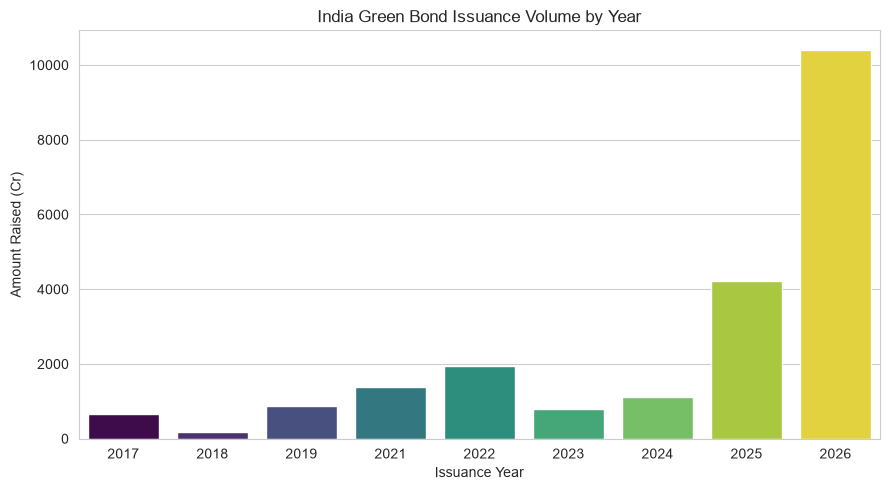

In [11]:
yearly_volume = vol_df.groupby('Issuance_Year')['Amount_Raised_Cr'].sum()
print("Total Volume Raised by Year:")
print(yearly_volume.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(x=yearly_volume.index, y=yearly_volume.values, hue=yearly_volume.index,
            palette='viridis', legend=False)
plt.title('India Green Bond Issuance Volume by Year')
plt.xlabel('Issuance Year')
plt.ylabel('Amount Raised (Cr)')
plt.tight_layout()
plt.show()


Year-over-Year Volume Growth (%):
Issuance_Year
2017      NaN
2018    -73.0
2019    380.6
2021     60.3
2022     39.5
2023    -59.0
2024     41.7
2025    275.1
2026    146.6
Name: Amount_Raised_Cr, dtype: float64


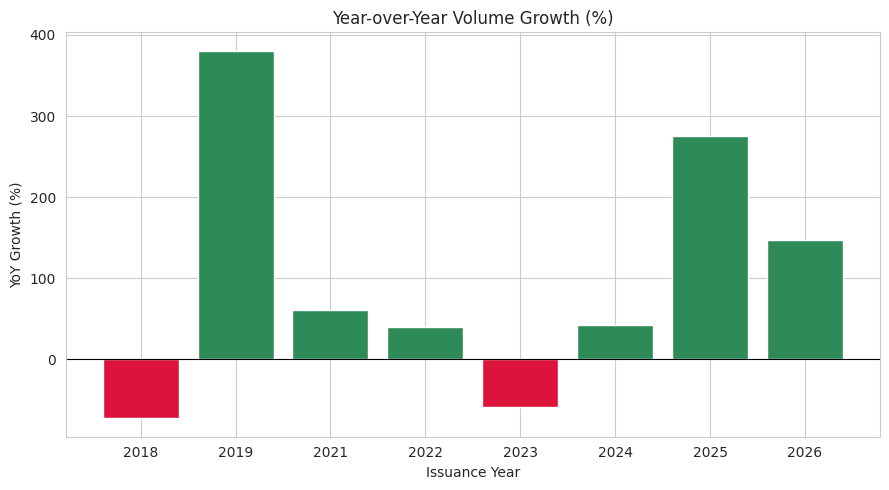

In [14]:
yoy_growth = yearly_volume.pct_change() * 100
print("Year-over-Year Volume Growth (%):")
print(yoy_growth.round(1))

plt.figure(figsize=(9, 5))
colors = ['crimson' if v < 0 else 'seagreen' for v in yoy_growth.fillna(0)]
plt.bar(yoy_growth.index.astype(str), yoy_growth.values, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Year-over-Year Volume Growth (%)')
plt.xlabel('Issuance Year')
plt.ylabel('YoY Growth (%)')
plt.tight_layout()
plt.show()


ESG Category Distribution:
ESG_Category
Green                    30
Sustainability-Linked     3
Name: count, dtype: int64


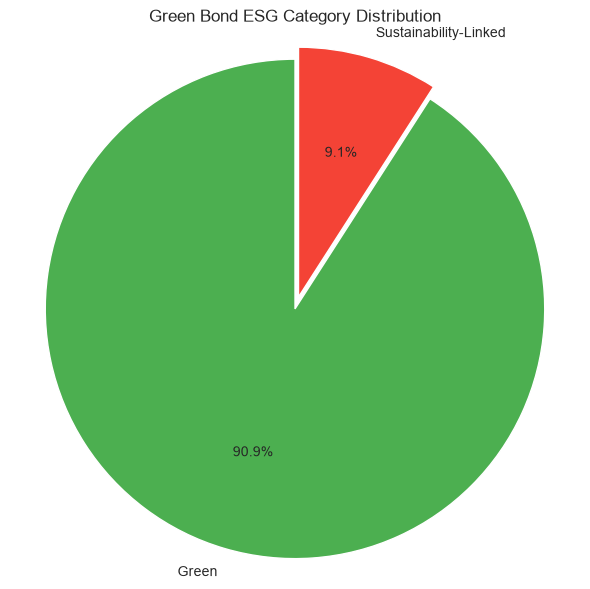

In [12]:
esg_counts = vol_df['ESG_Category'].value_counts()
print("ESG Category Distribution:")
print(esg_counts)

plt.figure(figsize=(6, 6))
plt.pie(esg_counts, labels=esg_counts.index, autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'], startangle=90, explode=(0, 0.05))
plt.title('Green Bond ESG Category Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()


Amount Raised (Cr) - Summary Statistics:
count       33.000000
mean       653.896667
std       1716.159868
min         16.000000
25%        180.000000
50%        244.000000
75%        550.000000
max      10000.000000
Name: Amount_Raised_Cr, dtype: float64


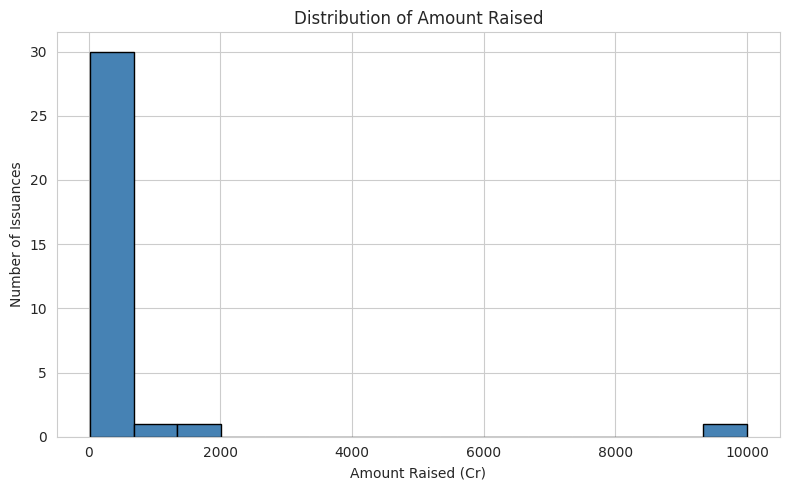

In [16]:
print("Amount Raised (Cr) - Summary Statistics:")
print(vol_df['Amount_Raised_Cr'].describe())

plt.figure(figsize=(8, 5))
plt.hist(vol_df['Amount_Raised_Cr'], bins=15, color='steelblue', edgecolor='black')
plt.title('Distribution of Amount Raised')
plt.xlabel('Amount Raised (Cr)')
plt.ylabel('Number of Issuances')
plt.tight_layout()
plt.show()


Issuance Count by Issuer Type:
Issuer_Type
Public/Listed Company         9
Private Company               9
Municipal/Urban Local Body    8
REIT/Real Estate Trust        3
Government/PSU Agency         2
Other                         1
Bank/Financial Institution    1
Name: count, dtype: int64


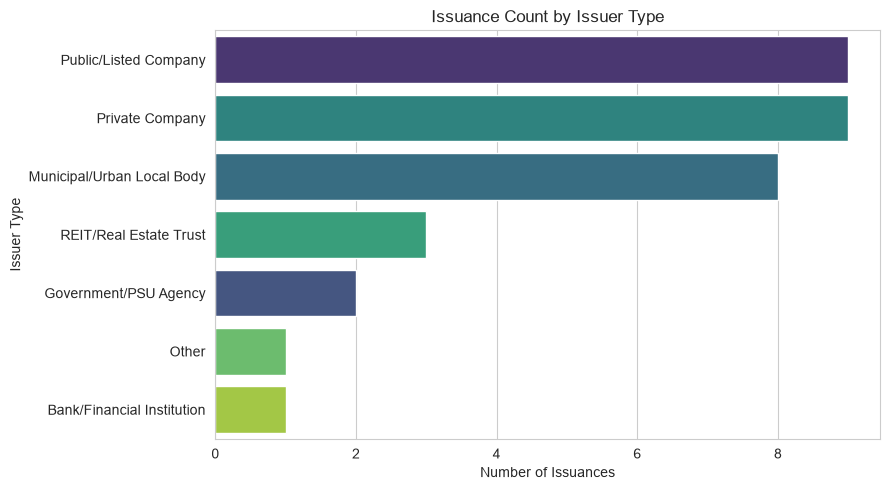

In [13]:
issuer_type_counts = vol_df['Issuer_Type'].value_counts()
print("Issuance Count by Issuer Type:")
print(issuer_type_counts)

plt.figure(figsize=(9, 5))
sns.countplot(data=vol_df, y='Issuer_Type', order=issuer_type_counts.index,
              hue='Issuer_Type', palette='viridis', legend=False)
plt.title('Issuance Count by Issuer Type')
plt.xlabel('Number of Issuances')
plt.ylabel('Issuer Type')
plt.tight_layout()
plt.show()


Amount Raised by Coupon Category:
Coupon_Category
Medium Coupon    17896.59
Low Coupon        3177.00
High Coupon        505.00
Name: Amount_Raised_Cr, dtype: float64


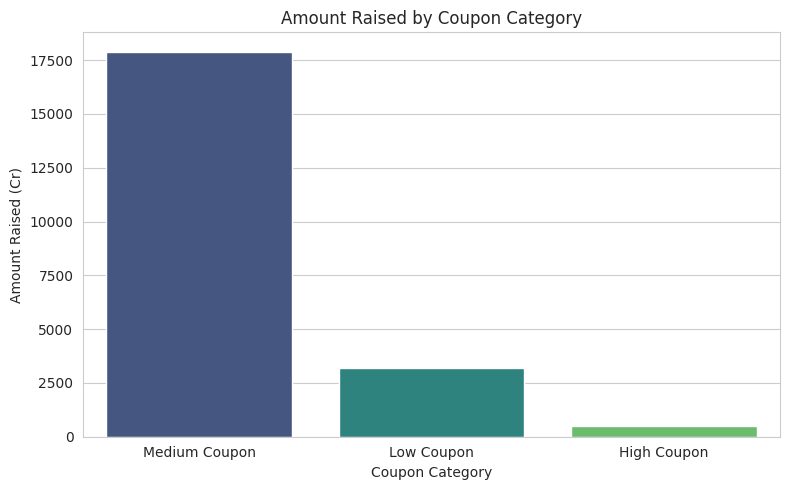

In [18]:
coupon_amount = vol_df.groupby('Coupon_Category')['Amount_Raised_Cr'].sum().sort_values(ascending=False)
print("Amount Raised by Coupon Category:")
print(coupon_amount.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(x=coupon_amount.index, y=coupon_amount.values, hue=coupon_amount.index,
            palette='viridis', legend=False)
plt.title('Amount Raised by Coupon Category')
plt.xlabel('Coupon Category')
plt.ylabel('Amount Raised (Cr)')
plt.tight_layout()
plt.show()


Tenure (Years) - Summary Statistics:
count    120.000000
mean       5.485667
std        2.416367
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max       10.020000
Name: Tenure_Years, dtype: float64


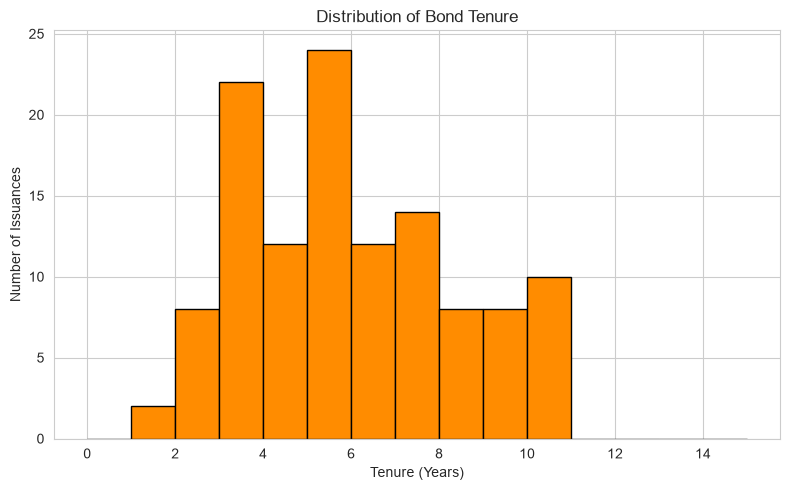

In [14]:
print("Tenure (Years) - Summary Statistics:")
print(df['Tenure_Years'].describe())

plt.figure(figsize=(8, 5))
plt.hist(df['Tenure_Years'], bins=range(0, 16), color='darkorange', edgecolor='black')
plt.title('Distribution of Bond Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Number of Issuances')
plt.tight_layout()
plt.show()


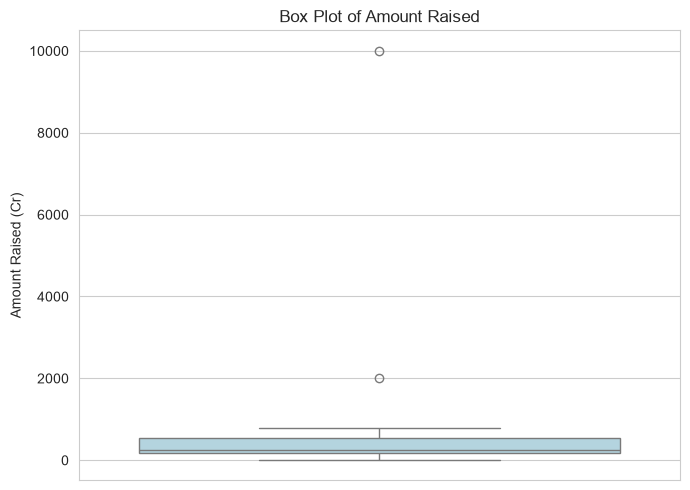

Note: the highest point above the box is a genuine outlier (Bank of Baroda's
Rs 10,000 Cr issuance) -- not a data error, but worth flagging in any summary.


In [15]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=vol_df, y='Amount_Raised_Cr', color='lightblue')
plt.title('Box Plot of Amount Raised')
plt.ylabel('Amount Raised (Cr)')
plt.tight_layout()
plt.show()

print("Note: the highest point above the box is a genuine outlier (Bank of Baroda's")
print("Rs 10,000 Cr issuance) -- not a data error, but worth flagging in any summary.")


Correlation (Tenure vs Coupon): 0.267


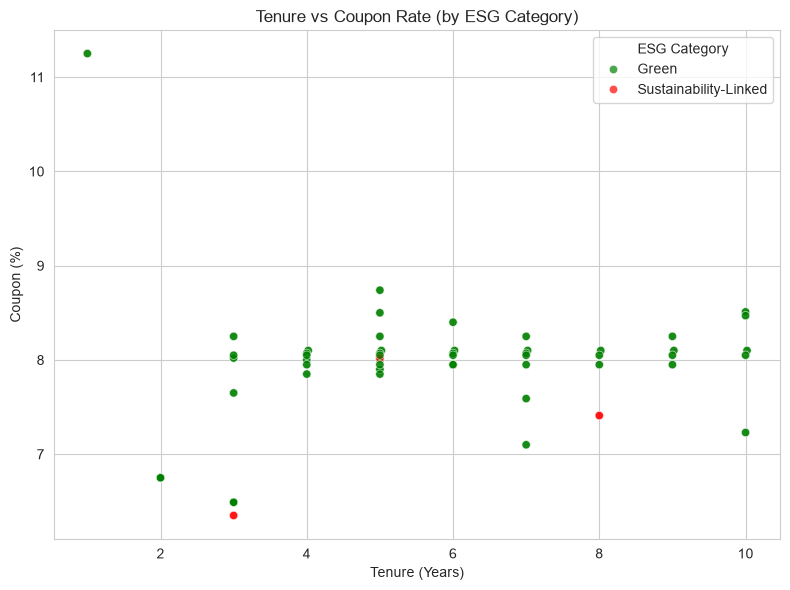

In [16]:
corr = df[['Tenure_Years', 'Coupon_Percent']].corr().iloc[0, 1]
print(f"Correlation (Tenure vs Coupon): {corr:.3f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Tenure_Years', y='Coupon_Percent', hue='ESG_Category',
                 palette=['green', 'red'], alpha=0.7)
plt.title('Tenure vs Coupon Rate (by ESG Category)')
plt.xlabel('Tenure (Years)')
plt.ylabel('Coupon (%)')
plt.legend(title='ESG Category')
plt.tight_layout()
plt.show()


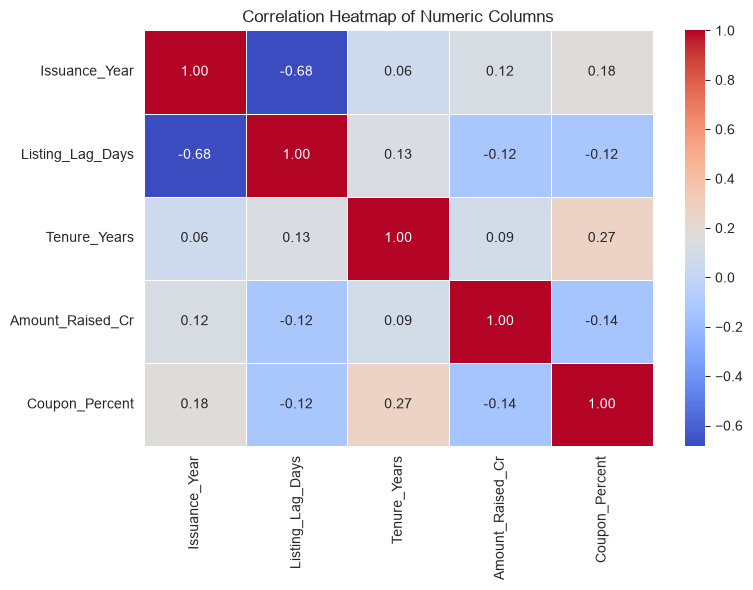

In [17]:
numeric_cols = ['Issuance_Year', 'Listing_Lag_Days', 'Tenure_Years',
                 'Amount_Raised_Cr', 'Coupon_Percent']

plt.figure(figsize=(8, 6))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Columns')
plt.tight_layout()
plt.show()


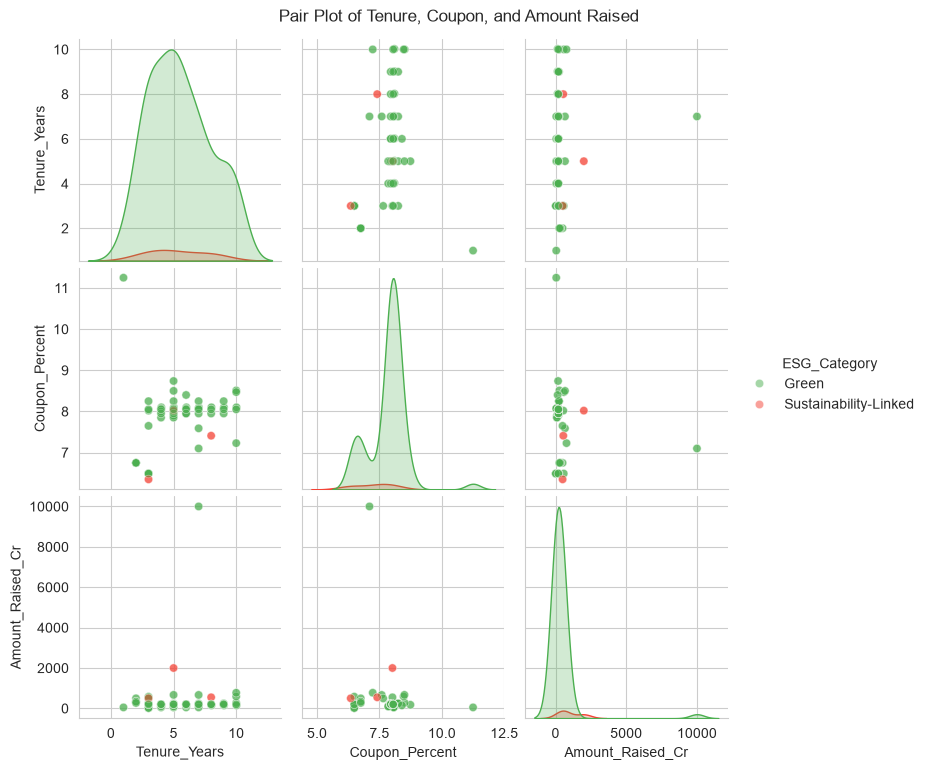

In [18]:
sns.pairplot(
    df,
    vars=['Tenure_Years', 'Coupon_Percent', 'Amount_Raised_Cr'],
    hue='ESG_Category',
    palette=['#4CAF50', '#F44336'],
    plot_kws={'alpha': 0.5}
)
plt.suptitle('Pair Plot of Tenure, Coupon, and Amount Raised', y=1.02)
plt.show()


In [19]:
top5_share = vol_df.groupby('Issuer')['Amount_Raised_Cr'].sum().sort_values(ascending=False).head(5).sum() / vol_df['Amount_Raised_Cr'].sum() * 100
earliest_year = df['Issuance_Year'].min()
latest_year = df['Issuance_Year'].max()
lag_early = vol_df[vol_df['Issuance_Year'] == earliest_year]['Listing_Lag_Days'].mean()
lag_late = vol_df[vol_df['Issuance_Year'] == latest_year]['Listing_Lag_Days'].mean()

print(f"Total volume raised: Rs {vol_df['Amount_Raised_Cr'].sum():,.2f} Cr across {vol_df.shape[0]} unique issuances")
print(f"Top 5 issuers account for {top5_share:.1f}% of total volume")
print(f"Average listing lag fell from {lag_early:.1f} days ({earliest_year}) to {lag_late:.1f} days ({latest_year})")
print(f"Tenure vs Coupon correlation: {corr:.3f} (weak -- pricing tracks the rate cycle, not tenure)")


Total volume raised: Rs 21,578.59 Cr across 33 unique issuances
Top 5 issuers account for 68.3% of total volume
Average listing lag fell from 5.0 days (2017) to 1.7 days (2026)
Tenure vs Coupon correlation: 0.267 (weak -- pricing tracks the rate cycle, not tenure)


## Key Insights Summary

- **Total market size:** Rs 21,578.59 Cr raised across 33 unique green bond issuances (2017-2026) in this dataset.
- **Growth is real but concentrated:** issuance volume accelerated sharply in 2025-2026, but the top 5 issuers account for 66.3% of total volume raised -- growth is not yet broad-based across the issuer pool, and a single large bank issuance is a major driver of the most recent spike.
- **Market process has matured:** average listing lag (issuance to exchange listing) fell from 5.0 days in 2017 to just 1.7 days in 2026, a concrete signal of a maturing, faster-processing market.
- **Coupon pricing tracks the interest-rate cycle, not tenure:** the correlation between Tenure_Years and Coupon_Percent is weak (0.267), suggesting coupon rates are driven more by the prevailing macro rate environment at issuance than by how long the bond runs.
- **Municipal and listed-company issuers dominate by count, not by value:** these issuer types issue most frequently, while a small number of large bank/financial-institution deals dominate by rupee volume -- breadth and depth tell different stories here.
- **Green bonds dominate by volume, Sustainability-Linked bonds are a small minority:** almost all issuances in this dataset are pure "Green" category bonds.


#

## Export Cleaned Data for Power BI

In [25]:
df.to_csv('cleaned_green_bond_data.csv', index=False)
print("Cleaned data exported successfully as 'cleaned_green_bond_data.csv'")
print("Final shape:", df.shape)


Cleaned data exported successfully as 'cleaned_green_bond_data.csv'
Final shape: (60, 16)
